# Оценка модели SSD300 (Object Detection)
**Датасет:** BCCD (Blood Cell Count Dataset)  
**Архитектура:** Single Shot Detector (VGG16 Base)  
**Классы:** RBC (Эритроциты), WBC (Лейкоциты), Platelets (Тромбоциты)

В данном ноутбуке мы проводим итоговую валидацию обученной модели:
1. Вычисление метрики **mAP** (Mean Average Precision) на валидационной выборке.
2. Визуальное сравнение предсказаний с истинной разметкой.

In [5]:
import json
import random
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from torchvision import transforms
from tqdm.notebook import tqdm

from model.datasets import PascalVOCDataset
from model.utils import *

# Инициализация устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

# Загружаем обученную модель
checkpoint = torch.load('checkpoint_ssd300.pth.tar', weights_only=False, map_location=device)
model = checkpoint['model']
model = model.to(device)
model.eval()
print("Модель успешно загружена!")

Используемое устройство: cuda
Модель успешно загружена!


## 1. Количественная оценка (mAP)
Мы вычисляем Average Precision для каждого класса и усредняем их

In [6]:
val_dataset = PascalVOCDataset('./data/', split='val')
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=val_dataset.collate_fn)

def evaluate_metrics(loader, model):
    det_boxes, det_labels, det_scores = [], [], []
    true_boxes, true_labels = [], []

    with torch.no_grad():
        for images, boxes, labels in tqdm(loader, desc='Оценка mAP'):
            images = images.to(device)
            predicted_locs, predicted_scores = model(images)
            
            det_boxes_batch, det_labels_batch, det_scores_batch = model.detect_objects(
                predicted_locs, predicted_scores, min_score=0.01, max_overlap=0.45, top_k=200
            )

            boxes = [b.to(device) for b in boxes]
            labels = [l.to(device) for l in labels]

            det_boxes.extend(det_boxes_batch)
            det_labels.extend(det_labels_batch)
            det_scores.extend(det_scores_batch)
            true_boxes.extend(boxes)
            true_labels.extend(labels)

        APs, mAP = calculate_mAP(det_boxes, det_labels, det_scores, true_boxes, true_labels)
        
    return APs, mAP

# Запускаем оценку
APs, mAP = evaluate_metrics(val_loader, model)

print('-' * 40)
print('Average Precision (AP) по классах:')
for class_name, ap in APs.items():
    print(f"  {class_name.capitalize():<10} : {ap:.3f}")
print('-' * 40)
print(f'Mean Average Precision (mAP): {mAP:.3f}')

Оценка mAP:   0%|          | 0/5 [00:00<?, ?it/s]

----------------------------------------
Average Precision (AP) по классах:
  Rbc        : 0.779
  Wbc        : 1.000
  Platelets  : 0.821
----------------------------------------
Mean Average Precision (mAP): 0.867


## 2. Качественная оценка (Визуализация)
Сравним истинную разметку человека с предсказаниями обученной нейросети на случайном изображении из валидационной выборки.
Здесь мы ставим более высокий порог `min_score = 0.45` для чистоты визуализации.

Анализируется файл: BloodImage_00233.jpg


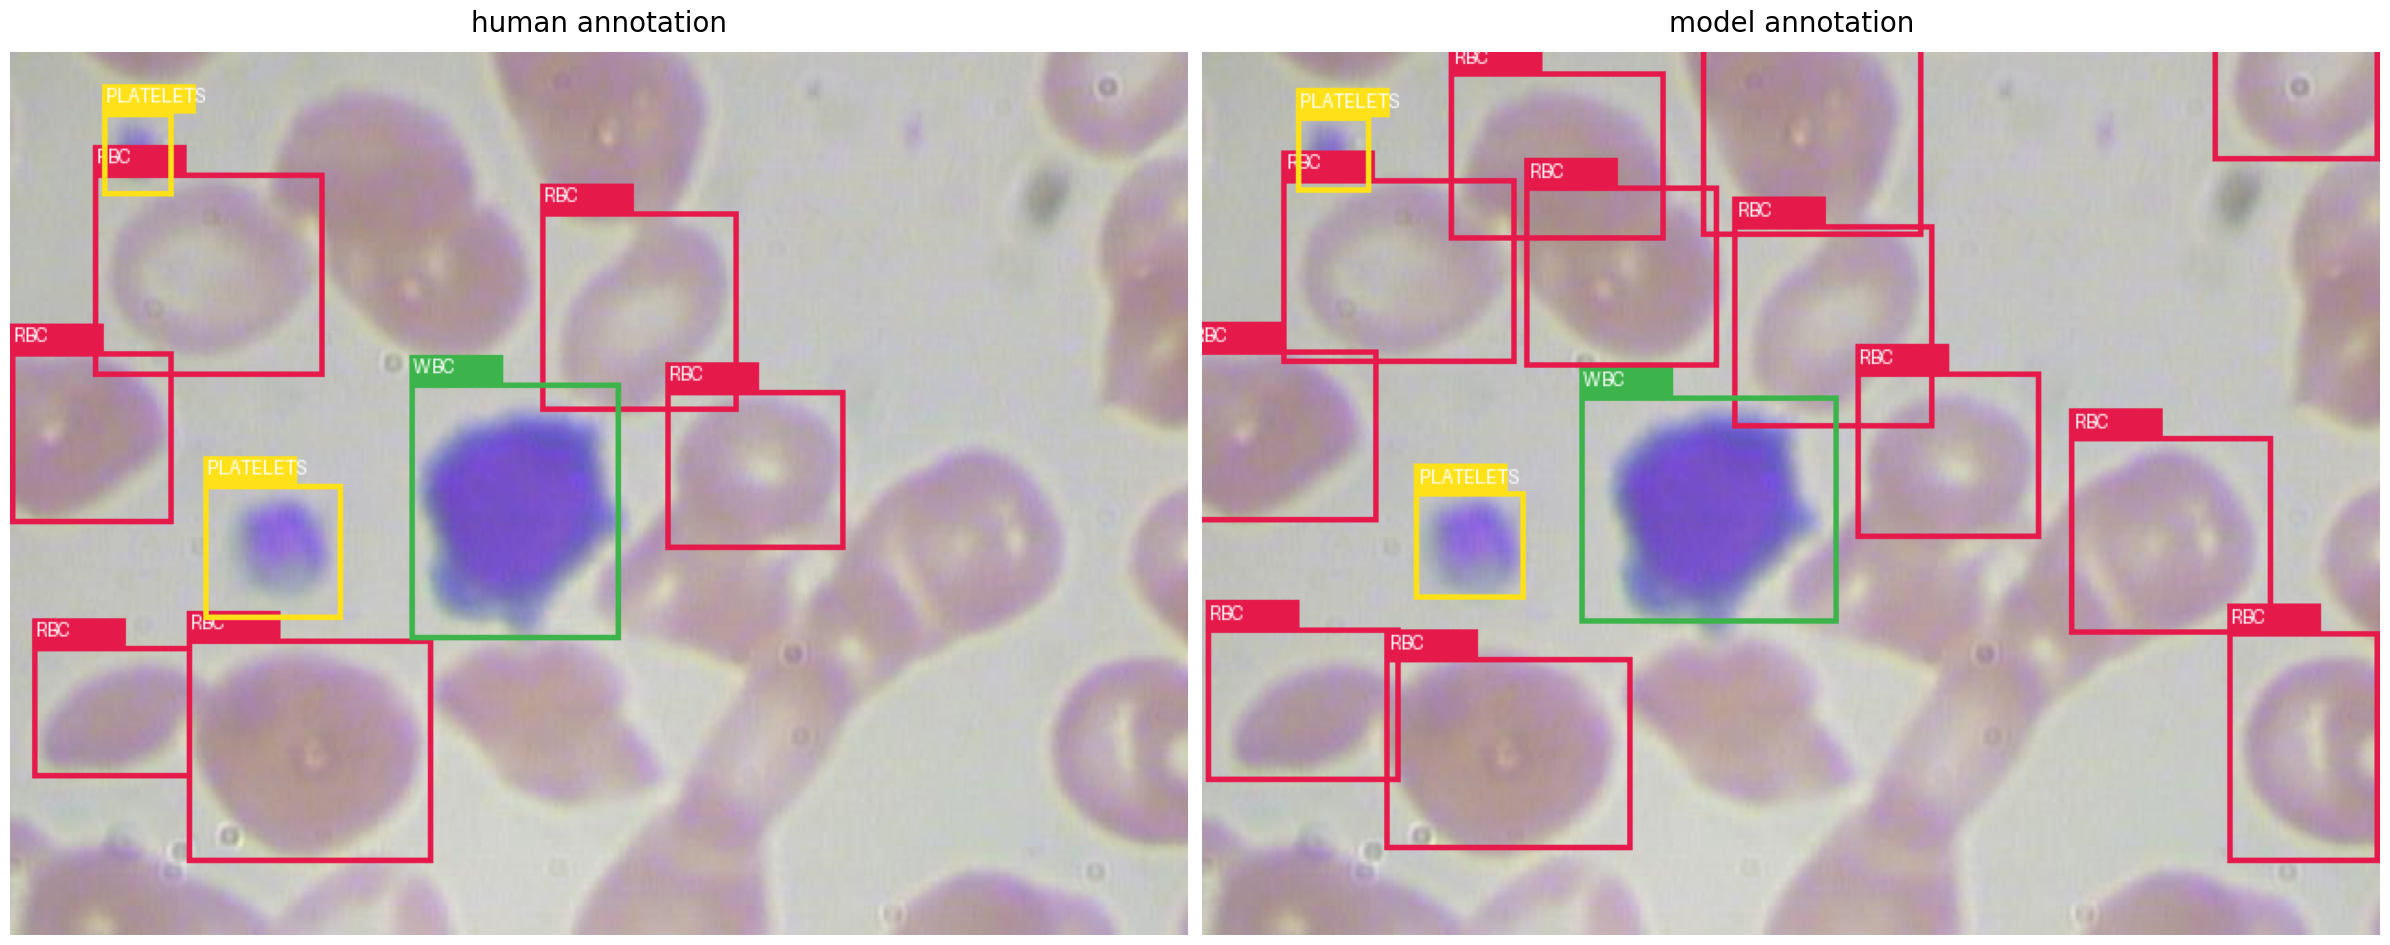

In [10]:
def detect_and_show(image, min_score=0.45, max_overlap=0.2, top_k=200):
    transform = transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        predicted_locs, predicted_scores = model(image_tensor)
        det_boxes, det_labels, det_scores = model.detect_objects(
            predicted_locs, predicted_scores, min_score=min_score, max_overlap=max_overlap, top_k=top_k
        )
        
    det_boxes = det_boxes[0].to('cpu')
    det_labels = det_labels[0].to('cpu').tolist()
    
    annotated_image = image.copy()
    draw = ImageDraw.Draw(annotated_image)
    
    original_dims = torch.FloatTensor(
        [annotated_image.width, annotated_image.height, annotated_image.width, annotated_image.height]
    ).unsqueeze(0)
    det_boxes = det_boxes * original_dims
    
    for i in range(det_boxes.size(0)):
        box_location = det_boxes[i].tolist()
        label_id = det_labels[i]
        label_name = rev_label_map[label_id]
        
        draw.rectangle(xy=box_location, outline=label_color_map[label_name], width=3)
        draw.rectangle(xy=[box_location[0], box_location[1]-15, box_location[0]+50, box_location[1]], fill=label_color_map[label_name])
        draw.text((box_location[0]+2, box_location[1]-15), label_name.upper(), fill='white')
        
    return annotated_image

# Читаем данные JSON
with open('./data/VAL_images.json', 'r') as j:
    val_images = json.load(j)
with open('./data/VAL_objects.json', 'r') as j:
    val_objects = json.load(j)

# Берем случайную картинку
idx = random.randint(0, len(val_images) - 1)
img_path = val_images[idx]
gt_data = val_objects[idx]
print(f"Анализируется файл: {img_path.split('/')[-1]}")

original_image = Image.open(img_path, mode='r').convert('RGB')

# Рисуем Ground Truth
gt_image = original_image.copy()
draw_gt = ImageDraw.Draw(gt_image)
for i in range(len(gt_data['boxes'])):
    box = gt_data['boxes'][i]
    label_id = gt_data['labels'][i]
    label_name = rev_label_map[label_id]
    draw_gt.rectangle(xy=box, outline=label_color_map[label_name], width=3)
    draw_gt.rectangle(xy=[box[0], box[1]-15, box[0]+50, box[1]], fill=label_color_map[label_name])
    draw_gt.text((box[0]+2, box[1]-15), label_name.upper(), fill='white')

# Рисуем Prediction
pred_image = detect_and_show(original_image, min_score=0.45, max_overlap=0.2)

# Сравниваем
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 12))
ax1.imshow(gt_image)
ax1.set_title("human annotation", fontsize=20, pad=15)
ax1.axis('off')
ax2.imshow(pred_image)
ax2.set_title("model annotation", fontsize=20, pad=15)
ax2.axis('off')

plt.tight_layout()
plt.show()